# NETFLIX STOCK PRICE DATASET -

## 1. Import Libraries.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Data Loading.

In [5]:
df = pd.read_csv('Netflix Stock Price UC.csv')

## 3. Data Understanding.

### --> head , tail , info , describe , shape , column.

In [6]:
df.head(3)

,Date,Open,High,Low,Close,Adj Close,Volume
0,2018-02-05,262.000000,267.899994,250.029999,254.259995,254.259995,11896100
1,2018-02-06,247.699997,266.700012,245.000000,265.720001,265.720001,12595800
2,2018-02-07,266.579987,272.450012,264.329987,264.559998,264.559998,8981500


In [7]:
df.tail(3)

,Date,Open,High,Low,Close,Adj Close,Volume
1006,2022-02-02,448.250000,451.980011,426.480011,429.480011,429.480011,14346000
1007,2022-02-03,421.440002,429.260010,404.279999,405.600006,405.600006,9905200
1008,2022-02-04,407.309998,412.769989,396.640015,410.170013,410.170013,7782400


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1009 entries, 0 to 1008
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1009 non-null   str    
 1   Open       1009 non-null   float64
 2   High       1009 non-null   float64
 3   Low        1009 non-null   float64
 4   Close      1009 non-null   float64
 5   Adj Close  1009 non-null   float64
 6   Volume     1009 non-null   int64  
dtypes: float64(5), int64(1), str(1)
memory usage: 55.3 KB


In [9]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,1009.000000,1009.000000,1009.000000,1009.000000,1009.000000,1.009000e+03
mean,419.059673,425.320703,412.374044,419.000733,419.000733,7.570685e+06
std,108.537532,109.262960,107.555867,108.289999,108.289999,5.465535e+06
min,233.919998,250.649994,231.229996,233.880005,233.880005,1.144000e+06
25%,331.489990,336.299988,326.000000,331.619995,331.619995,4.091900e+06
50%,377.769989,383.010010,370.880005,378.670013,378.670013,5.934500e+06
75%,509.130005,515.630005,502.529999,509.079987,509.079987,9.322400e+06
max,692.349976,700.989990,686.090027,691.690002,691.690002,5.890430e+07


In [10]:
df.shape

(1009, 7)

In [11]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='str')

## 4. Data Cleaning & Processing.

### (i). To check NULL values & handle it.

In [12]:
df.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

### (ii). To check DUPLICATE values & handle it.

In [13]:
df.duplicated().sum()

np.int64(0)

### (iii). Columns & Columns data Transformation.

#### (a).  

In [14]:
df.columns = df.columns.str.lower().str.replace(' ' , '_')

#### (b).

In [15]:
df['date'] = pd.to_datetime(df['date'])

In [16]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['day_name'] = df['date'].dt.day_name()

#### (c).

In [17]:
df['price_range'] = df['high'] - df['low']

In [18]:
df['price_change'] = df['close'] - df['open']

In [19]:
df['daily_return'] = df['close'].pct_change() # In Percent(%)

In [20]:
df['market_trend'] = np.where(df['close'] > df['open'], 'Bullish',
                     np.where(df['close'] < df['open'], 'Bearish', 'Neutral'))

In [21]:
df['market_trend'].value_counts()

market_trend
Bearish    506
Bullish    502
Neutral      1
Name: count, dtype: int64

In [22]:
df['market_trend'].unique()

<StringArray>
['Bearish', 'Bullish', 'Neutral']
Length: 3, dtype: str

#### (d).

In [23]:
(df['close'] == df['adj_close']).all()

np.True_

In [24]:
df = df.drop('adj_close', axis=1)
#"The 'adj_close' column was removed as it contained identical values to the 'close' column, indicating no stock splits or dividend adjustments in
#the dataset."

#### (e).

In [25]:
df = df.dropna(subset=['daily_return'])
# "The initial null value in the daily return column, caused by percentage change calculation, was removed to ensure consistency in analysis."

In [26]:
df['daily_return'].isnull().sum()

np.int64(0)

#### (f).

In [27]:
df['volume_per_million'] = df['volume'] / 1_000_000

In [28]:
df=df.drop('volume' , axis=1)

#### (g).

In [29]:
df['volatility'] = df['daily_return'].rolling(7).std()
# "Rolling standard deviation over a 7-day window was used to measure short-term volatility and identify periods of high market fluctuation."

In [30]:
df = df.dropna(subset=['volatility'])
# "Initial null values in the volatility column were expected due to the rolling window calculation and were removed to maintain analytical accuracy."

In [31]:
df['volatility'].describe()

count    1002.000000
mean        0.023225
std         0.012928
min         0.005512
25%         0.014516
50%         0.020383
75%         0.027809
max         0.105514
Name: volatility, dtype: float64

In [32]:
high_vol = df[df['volatility'] > df['volatility'].mean()]
low_vol = df[df['volatility'] < df['volatility'].mean()]
#"Volatility analysis revealed periods of high market uncertainty, where price fluctuations were significant, indicating increased risk for investors."

In [33]:
df.head(3)

,date,open,high,low,close,year,month,day,day_name,price_range,price_change,daily_return,market_trend,volume_per_million,volatility
7,2018-02-14,260.470001,269.880005,260.329987,266.000000,2018,2,14,Wednesday,9.550018,5.529999,0.029930,Bullish,10.9720,0.033562
8,2018-02-15,270.029999,280.500000,267.630005,280.269989,2018,2,15,Thursday,12.869995,10.239990,0.053647,Bullish,10.7597,0.035296
9,2018-02-16,278.730011,281.959991,275.690002,278.519989,2018,2,16,Friday,6.269989,-0.210022,-0.006244,Bearish,8.3124,0.035415


#### Insight:-
* Stock experienced high volatility during certain periods, indicating unstable market behavior
* Low volatility phases showed steady price movement
* Sudden spikes in volatility may be linked to major events or news

#### (h).

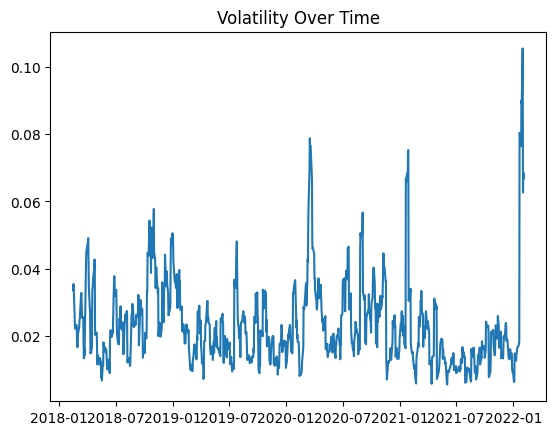

In [34]:
import matplotlib.pyplot as plt

plt.plot(df['date'], df['volatility'])
plt.title("Volatility Over Time")
plt.show()

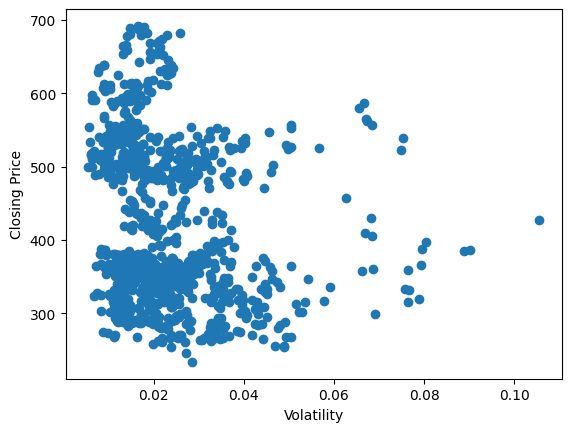

In [35]:
plt.scatter(df['volatility'], df['close'])
plt.xlabel("Volatility")
plt.ylabel("Closing Price")
plt.show()

In [36]:
df['risk_level'] = df['volatility'].apply(
    lambda x: 'High Risk' if x > df['volatility'].mean() else 'Low Risk'
)

In [37]:
high_vol.describe()
low_vol.describe()

,date,open,high,low,close,year,month,day,price_range,price_change,daily_return,volume_per_million,volatility
count,605,605.000000,605.000000,605.000000,605.000000,605.000000,605.000000,605.000000,605.000000,605.000000,605.000000,605.000000,605.000000
mean,2020-04-22 13:12:35.702479,439.612843,445.020495,433.982447,439.605470,2019.790083,6.761983,15.219835,11.038049,-0.007372,0.000889,5.650607,0.015553
min,2018-02-21 00:00:00,254.630005,265.500000,250.000000,258.820007,2018.000000,1.000000,1.000000,2.890015,-31.709960,-0.044907,1.144000,0.005512
25%,2019-05-16 00:00:00,346.910004,349.950012,342.059998,345.869995,2019.000000,5.000000,8.000000,7.489991,-4.119995,-0.010174,3.360600,0.012394
50%,2020-05-15 00:00:00,421.399994,427.100006,413.079987,419.730011,2020.000000,7.000000,15.000000,9.859985,-0.009949,0.000782,4.935700,0.015747
75%,2021-06-08 00:00:00,525.530029,533.260010,519.390015,525.690002,2021.000000,10.000000,22.000000,13.149994,3.980011,0.011133,6.689700,0.018860
max,2022-01-20 00:00:00,692.349976,700.989990,686.090027,691.690002,2022.000000,12.000000,31.000000,37.450013,24.269958,0.048406,38.258900,0.023218
std,NaN,112.541445,113.482282,111.153894,112.071612,1.142453,3.311561,8.563723,5.094871,6.738458,0.015953,3.416982,0.004284


#### (i).

In [38]:
#"Columns were reorganized into a structured format including raw price data, time-based features, engineered metrics, and trend indicators for
#improved readability and analysis."

In [39]:
df['ma_7'] = df['close'].rolling(7).mean()
df['ma_30'] = df['close'].rolling(30).mean()

In [40]:
#### USES:-
# * MA short > MA long → Bullish trend 
# * MA short < MA long → Bearish trend 

In [41]:
df = df.dropna(subset=['ma_7', 'ma_30'])
# "Initial null values in moving averages were expected due to rolling window calculations and were removed to ensure analytical consistency."

In [42]:
df.reset_index(drop=True, inplace=True)

#### (j).

In [43]:
df.columns

Index(['date', 'open', 'high', 'low', 'close', 'year', 'month', 'day',
       'day_name', 'price_range', 'price_change', 'daily_return',
       'market_trend', 'volume_per_million', 'volatility', 'risk_level',
       'ma_7', 'ma_30'],
      dtype='str')

In [44]:
df = df[[
    # 🟢 Date
    'date',
    
    # 🟢 Original Price Data
    'open', 'high', 'low', 'close',
    
    # 🟢 Time Features
    'year', 'month', 'day', 'day_name',
    
    # 🟢 Price-Based Features
    'price_change', 'price_range', 'daily_return',
    
    # 🟢 Trend / Indicators
    'ma_7', 'ma_30', 'volatility' , 'risk_level',
    
    # 🟢 Volume Feature
    'volume_per_million',
    
    # 🟢 Labels / Classification
    'market_trend'
]
]

#### (k).

In [45]:
cols = ['open' , 'close' , 'high' , 'low' , 'price_change' , 'price_range' , 'daily_return' , 'ma_7' , 'ma_30' , 'volatility' , 'volume_per_million']
df[cols] = df[cols].round(2)

In [46]:
df.head()

,date,open,high,low,close,year,month,day,day_name,price_change,price_range,daily_return,ma_7,ma_30,volatility,risk_level,volume_per_million,market_trend
0,2018-03-28,298.39,298.80,281.61,285.77,2018,3,28,Wednesday,-12.62,17.19,-0.05,306.92,302.87,0.04,High Risk,18.97,Bearish
1,2018-03-29,287.00,295.35,275.90,295.35,2018,3,29,Thursday,8.35,19.45,0.03,303.75,303.85,0.05,High Risk,19.15,Bullish
2,2018-04-02,291.94,292.87,275.05,280.29,2018,4,2,Monday,-11.65,17.82,-0.05,298.58,303.85,0.05,High Risk,13.41,Bearish
3,2018-04-03,285.45,291.25,278.01,283.67,2018,4,3,Tuesday,-1.78,13.24,0.01,295.29,304.02,0.05,High Risk,12.69,Bearish
4,2018-04-04,273.63,290.31,271.22,288.94,2018,4,4,Wednesday,15.31,19.09,0.02,293.58,304.37,0.05,High Risk,12.91,Bullish


In [47]:
df['day_name'].unique()

<StringArray>
['Wednesday', 'Thursday', 'Monday', 'Tuesday', 'Friday']
Length: 5, dtype: str

In [48]:
df['month'].unique()

array([ 3,  4,  5,  6,  7,  8,  9, 10, 11, 12,  1,  2], dtype=int32)

In [49]:
df['risk_level'].unique()

<StringArray>
['High Risk', 'Low Risk']
Length: 2, dtype: str

In [50]:
df['market_trend'].unique()

<StringArray>
['Bearish', 'Bullish', 'Neutral']
Length: 3, dtype: str

#### (l).

In [55]:
df.rename(columns={'daily_return': 'pct_gain_loss'}, inplace=True)

In [56]:
df['pct_gain_loss'] = df['pct_gain_loss'] * 100

## 5. EDA & Data Analysis/ Visualize = Insights + Recommendation.

### --> DATA VISUALIZATION :-

### 1. Stock Price Trend.

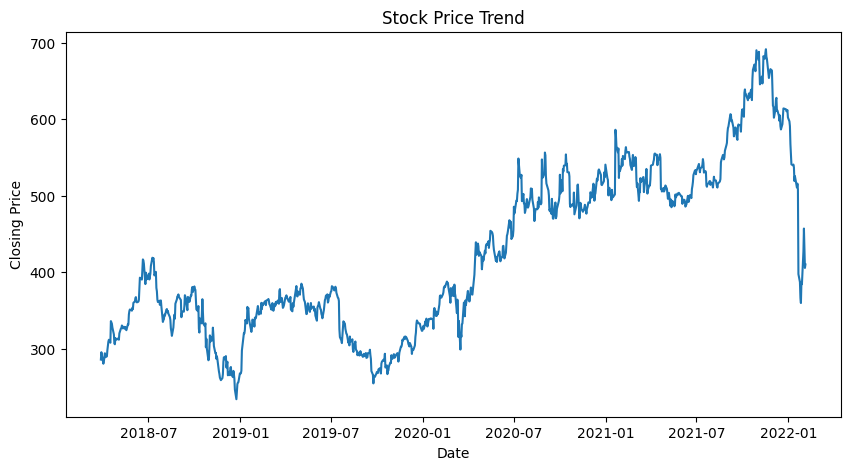

In [76]:
plt.figure(figsize=(10,5))
plt.plot(df['date'], df['close'])
plt.title("Stock Price Trend")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.savefig("stock_price_trend.png")  
plt.show()

### 2. Moving Average Comparison.

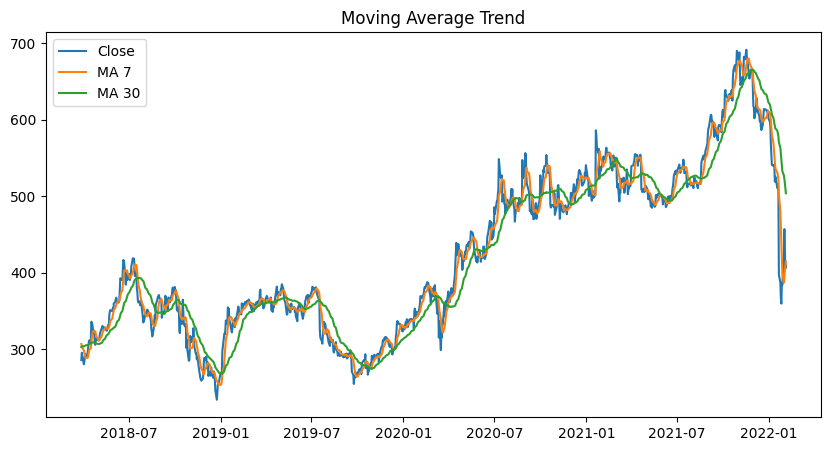

In [78]:
plt.figure(figsize=(10,5))
plt.plot(df['date'], df['close'], label='Close')
plt.plot(df['date'], df['ma_7'], label='MA 7')
plt.plot(df['date'], df['ma_30'], label='MA 30')
plt.legend()
plt.title("Moving Average Trend")
plt.savefig("Moving_Average_Comp.png")
plt.show()

### 3. Volatility Over Time.

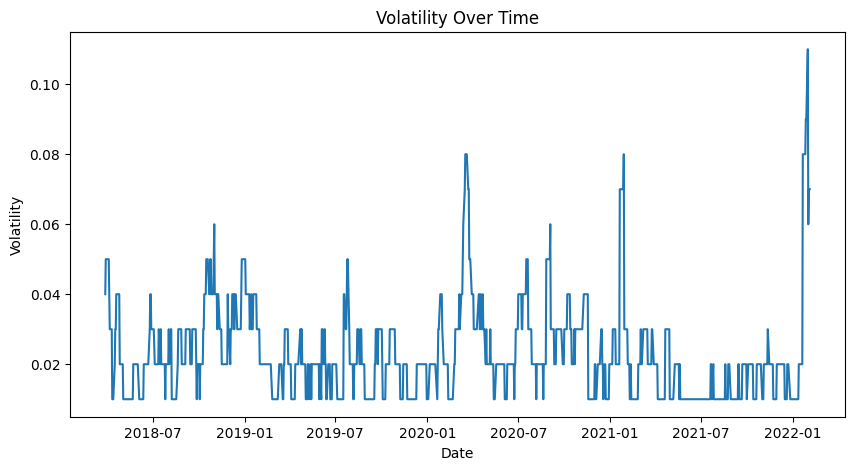

In [80]:
plt.figure(figsize=(10,5))
plt.plot(df['date'], df['volatility'])
plt.title("Volatility Over Time")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.savefig("Volatility_over_time.png")
plt.show()

### 4. Volume Analysis.

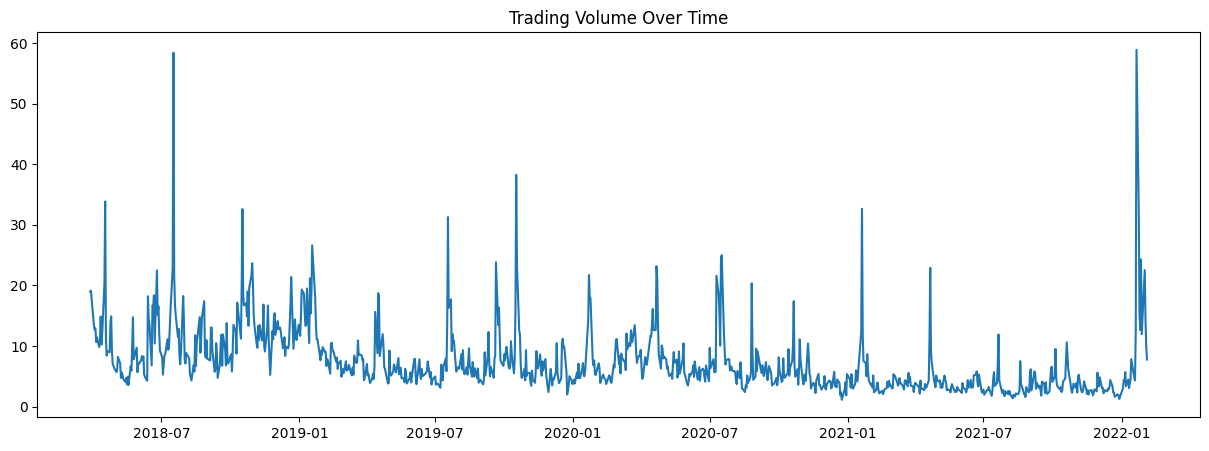

In [88]:
plt.figure(figsize=(15,5))
plt.plot(df['date'], df['volume_per_million'])
plt.title("Trading Volume Over Time")
plt.savefig("Volume_Analysis.png")
plt.show()

### 5. Daily Return Distribution.

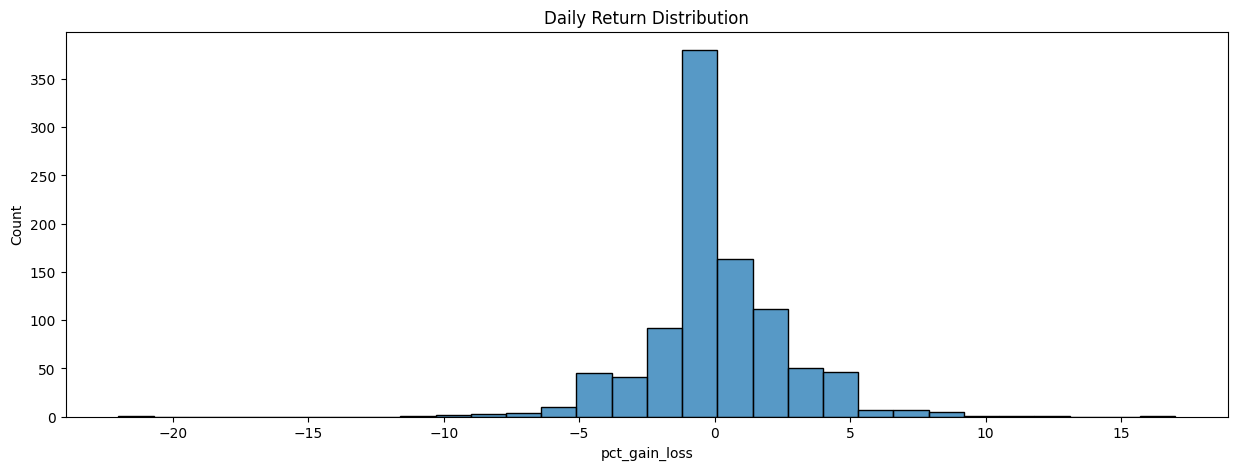

In [91]:
plt.figure(figsize=(15,5))
sns.histplot(df['pct_gain_loss'], bins=30)
plt.title("Daily Return Distribution")
plt.savefig("Daily_Return_Dist.png")
plt.show()

### 6. Market Trend Distribution.

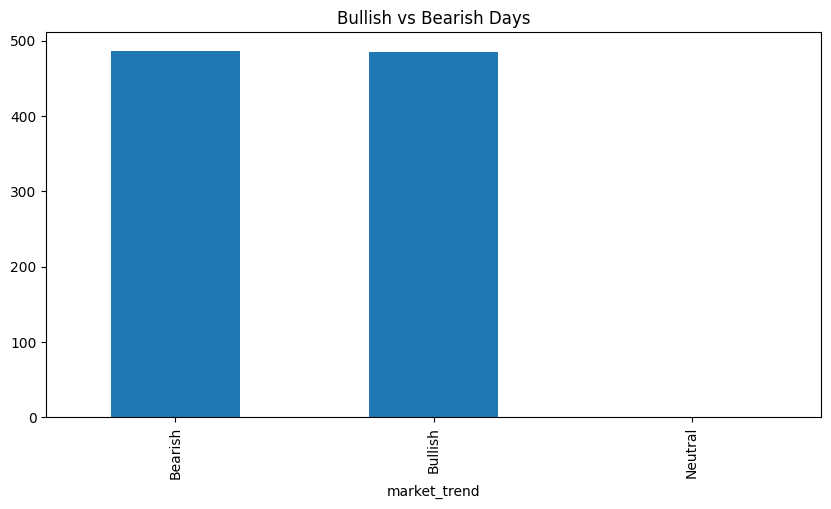

In [94]:
plt.figure(figsize=(10,5))
df['market_trend'].value_counts().plot(kind='bar')
plt.title("Bullish vs Bearish Days")
plt.savefig("Market_Trend_Dist.png")
plt.show()

### 7. Volatility vs Return.

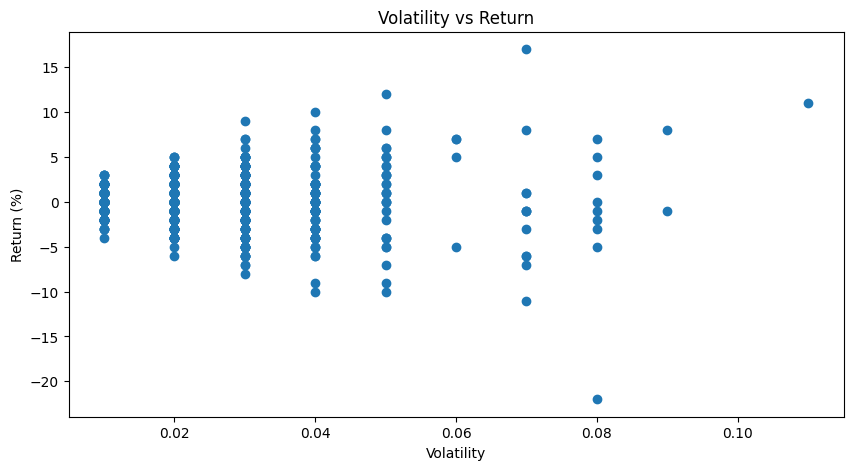

In [98]:
plt.figure(figsize=(10,5))
plt.scatter(df['volatility'], df['pct_gain_loss'])
plt.xlabel("Volatility")
plt.ylabel("Return (%)")
plt.title("Volatility vs Return")
plt.savefig("Volatility_return.png")
plt.show()

### 8. Day-wise Performance.

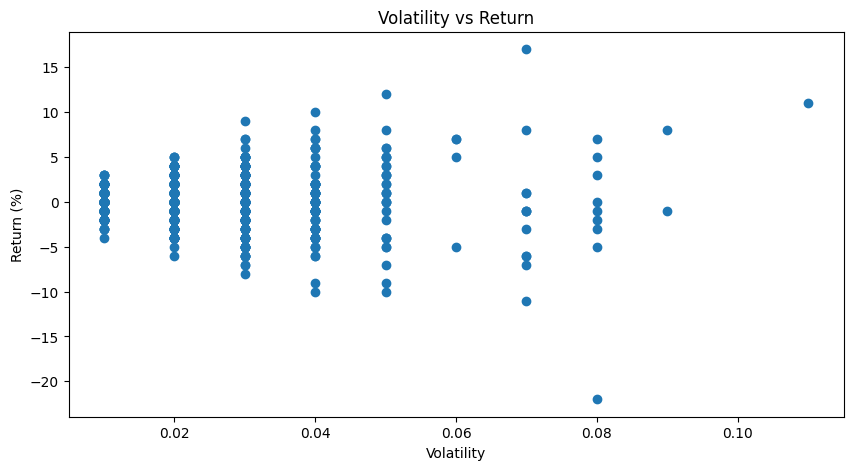

In [99]:
plt.figure(figsize=(10,5))
plt.scatter(df['volatility'], df['pct_gain_loss'])
plt.xlabel("Volatility")
plt.ylabel("Return (%)")
plt.title("Volatility vs Return")
plt.savefig("Day-wise Performance.png")
plt.show()

## --> Observations (Clean & Professional)
* The stock price shows continuous fluctuations, indicating an active and dynamic market.
* Both positive and negative returns are present, reflecting frequent profit and loss cycles.
* Volatility varies over time, indicating periods of stability and instability.
* Moving averages smooth out price trends and highlight underlying market direction.
* Trading volume fluctuates, suggesting varying levels of market participation.

### --> Insights (Strong Analytical Thinking)
* High volatility periods indicate increased market uncertainty and risk.
* Short-term trends react faster to price changes, while long-term trends provide stability.
* Frequent alternation between profit and loss days suggests active trading behavior.
* Higher trading volumes often align with significant price movements.
* Trend patterns suggest the presence of both short-term momentum and long-term growth phases.

### --> Recommendations
* Investors should be cautious during high volatility periods due to increased risk.
* Short-term traders can use moving averages to capture quick opportunities.
* Long-term investors should rely on stable trend indicators like MA_30.
* High volume periods can be used to identify potential entry and exit points.
* Combining volatility and trend indicators can improve decision-making accuracy.

## "The analysis reveals dynamic stock behavior influenced by volatility, trading activity, and trend patterns, offering valuable insights for both short-term and long-term investment strategies."

In [103]:
df.to_csv("Netflix Stock Price C.csv" , index=False)

In [105]:
import os
os.getcwd()

'C:\\Users\\MY PC'